In [1]:
import joblib

calibrated_rf = joblib.load("calibrated_rf.pkl")
optimal_threshold = joblib.load("optimal_threshold.pkl")

X_test = joblib.load("X_test.pkl")
y_test = joblib.load("y_test.pkl")

y_proba = calibrated_rf.predict_proba(X_test)[:,1]


In [6]:
optimal_threshold

np.float64(0.2306122448979592)

In [2]:
C_FP = 1
C_FN = 5


In [3]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

thresholds = np.linspace(0.1, 0.9, 50)

cost_results = []

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    expected_cost = C_FP * fp + C_FN * fn
    
    cost_results.append([t, expected_cost])

cost_df = pd.DataFrame(cost_results, columns=["threshold", "expected_cost"])


In [4]:
best_cost_row = cost_df.loc[cost_df["expected_cost"].idxmin()]
best_cost_row
# the best cost treshold

threshold          0.165306
expected_cost    123.000000
Name: 4, dtype: float64

In [7]:
best_cost_threshold = best_cost_row["threshold"]
best_cost_threshold


np.float64(0.1653061224489796)

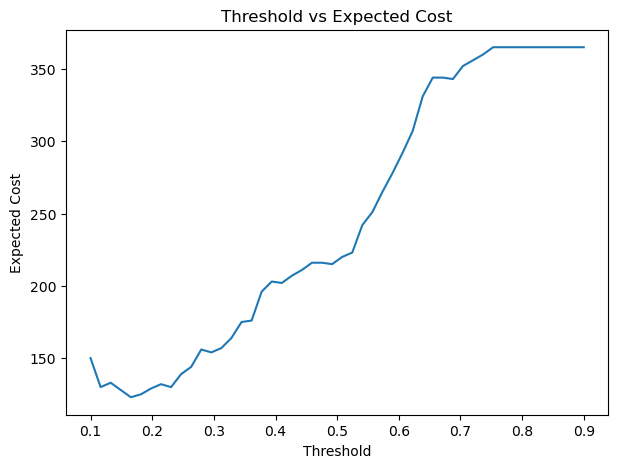

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(cost_df["threshold"], cost_df["expected_cost"])
plt.xlabel("Threshold")
plt.ylabel("Expected Cost")
plt.title("Threshold vs Expected Cost")
plt.show()


### The cost-optimal threshold is lower than the F1-optimal threshold, indicating that minimizing operational cost requires prioritizing recall over precision. Since false negatives carry a higher penalty in our cost framework, the model shifts toward a more recall-oriented decision boundary. This demonstrates that metric-based optimization (F1) does not necessarily align with real-world decision objectives.

### This highlights the importance of aligning model decision thresholds with domain-specific risk tolerance rather than relying solely on generic performance metrics.

In [8]:
import joblib

joblib.dump(best_cost_threshold, "best_cost_threshold.pkl")


['best_cost_threshold.pkl']